In [64]:
import warnings
warnings.filterwarnings("ignore")

import os, time, multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from joblib import Parallel, delayed

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

GPU_AVAILABLE = False
try:
    import cudf, cuml
    from cuml.linear_model import LinearRegression as cuLR
    GPU_AVAILABLE = True
    print("RAPIDS cuML — GPU ON")
except ImportError:
    print("CPU mode — sklearn")


N_JOBS = multiprocessing.cpu_count()
print(f"Parallel workers : {N_JOBS}")
print(f"numpy  : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"GPU    : {GPU_AVAILABLE}")

RAPIDS cuML — GPU ON
Parallel workers : 4
numpy  : 2.0.2
pandas : 2.3.3
GPU    : True


In [65]:
DATA_PATH = "/kaggle/input/datasets/ashifaikram/ds-salaries/ds_salaries.csv"

try:
    df_raw = pd.read_csv(DATA_PATH)
    print("Dataset loaded:", df_raw.shape)
    print(df_raw.head())
    USE_REAL = True
except FileNotFoundError:
    print("File not found — generating synthetic data")
    USE_REAL = False
    np.random.seed(42)
    N = 500
    exp   = np.random.randint(0, 21, N)
    score = np.round(np.random.uniform(50, 100, N), 1)
    dept  = np.random.choice(["Engineering","Marketing","Finance","HR","Sales"], N)
    edu   = np.random.choice(["Bachelor","Master","PhD"], N, p=[0.5,0.35,0.15])
    d_b   = {"Engineering":15000,"Finance":10000,"Marketing":5000,"HR":2000,"Sales":7000}
    e_b   = {"Bachelor":0,"Master":8000,"PhD":18000}
    sal   = (
        30000 + exp*2500 + (score-50)*300
        + np.array([d_b[d] for d in dept])
        + np.array([e_b[e] for e in edu])
        + np.random.normal(0, 5000, N)
    ).round(2)
    df_raw = pd.DataFrame({
        "experience_level": np.random.choice(["EN","MI","SE","EX"], N),
        "employment_type":  np.random.choice(["FT","PT","CT","FL"], N),
        "salary_in_usd":    sal,
        "remote_ratio":     np.random.choice([0, 50, 100], N),
        "company_size":     np.random.choice(["S","M","L"], N),
    })
    print(df_raw.head())

Dataset loaded: (607, 12)
   Unnamed: 0  work_year experience_level employment_type  \
0           0       2020               MI              FT   
1           1       2020               SE              FT   
2           2       2020               SE              FT   
3           3       2020               MI              FT   
4           4       2020               SE              FT   

                    job_title  salary salary_currency  salary_in_usd  \
0              Data Scientist   70000             EUR          79833   
1  Machine Learning Scientist  260000             USD         260000   
2           Big Data Engineer   85000             GBP         109024   
3        Product Data Analyst   20000             USD          20000   
4   Machine Learning Engineer  150000             USD         150000   

  employee_residence  remote_ratio company_location company_size  
0                 DE             0               DE            L  
1                 JP             0      

In [66]:
print("Shape   :", df_raw.shape)
print("Columns :", df_raw.columns.tolist())
print("\nMissing Values:")
print(df_raw.isnull().sum())
print("\nStatistics:")
print(df_raw.describe().round(2))

Shape   : (607, 12)
Columns : ['Unnamed: 0', 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Missing Values:
Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Statistics:
       Unnamed: 0  work_year       salary  salary_in_usd  remote_ratio
count      607.00     607.00       607.00         607.00        607.00
mean       303.00    2021.41    324000.06      112297.87         70.92
std        175.37       0.69   1544357.49       70957.26         40.71
min          0.00    2020.00      4000.00        2859.00          0.00
25%        151.50    2021.00     70000.00       62726.00         50.00
50%        30

In [67]:
# Select & clean relevant columns
TARGET = "salary_in_usd"

CATEGORICAL = [c for c in ["experience_level", "employment_type",
                             "company_size", "job_title"] if c in df_raw.columns]
NUMERICAL   = [c for c in ["remote_ratio"] if c in df_raw.columns]

df = df_raw[CATEGORICAL + NUMERICAL + [TARGET]].dropna().copy()

print(f"Dataset shape after cleaning : {df.shape}")
print(f"Categorical features : {CATEGORICAL}")
print(f"Numerical features   : {NUMERICAL}")
print(f"Target               : {TARGET}\n")

# Outlier Removal
Q1 = df[TARGET].quantile(0.05)
Q3 = df[TARGET].quantile(0.95)
before = len(df)
df = df[(df[TARGET] >= Q1) & (df[TARGET] <= Q3)].copy()
after  = len(df)
print(f"Outlier removal  : {before} → {after} rows")
print(f"Salary range now : ${df[TARGET].min():,.0f} → ${df[TARGET].max():,.0f}\n")

if "work_year" in df_raw.columns:
    df["years_since_start"] = df_raw.loc[df.index, "work_year"].values - 2020
    NUMERICAL = NUMERICAL + ["years_since_start"]
    print(f"Relative year added : years_since_start → {sorted(df['years_since_start'].unique())}")

# Parallel label encoding 
def encode_column(series):
    """Encode one categorical column"""
    le = LabelEncoder()
    return series.name, le.fit_transform(series.astype(str)), le

results = Parallel(n_jobs=N_JOBS, backend="loky")(
    delayed(encode_column)(df[col]) for col in CATEGORICAL
)

label_encoders = {}
for col_name, encoded_vals, le in results:
    df[col_name] = encoded_vals
    label_encoders[col_name] = le
    print(f"  Encoded '{col_name}' → {len(le.classes_)} unique classes  "
          f"{list(le.classes_[:4])}{'...' if len(le.classes_) > 4 else ''}")

print(f"\nPreprocessing done | final shape: {df.shape}")
print(df.head())

Dataset shape after cleaning : (607, 6)
Categorical features : ['experience_level', 'employment_type', 'company_size', 'job_title']
Numerical features   : ['remote_ratio']
Target               : salary_in_usd

Outlier removal  : 607 → 547 rows
Salary range now : $20,000 → $220,110

Relative year added : years_since_start → [np.int64(0), np.int64(1), np.int64(2)]
  Encoded 'experience_level' → 4 unique classes  ['EN', 'EX', 'MI', 'SE']
  Encoded 'employment_type' → 4 unique classes  ['CT', 'FL', 'FT', 'PT']
  Encoded 'company_size' → 3 unique classes  ['L', 'M', 'S']
  Encoded 'job_title' → 48 unique classes  ['AI Scientist', 'Analytics Engineer', 'Applied Data Scientist', 'Applied Machine Learning Scientist']...

Preprocessing done | final shape: (547, 7)
   experience_level  employment_type  company_size  job_title  remote_ratio  \
0                 2                2             0         20             0   
2                 3                2             1          6            50 

In [68]:
ALL_FEATURES = CATEGORICAL + NUMERICAL
#  single vs multiple comparison
subsets = {
    "Single (experience_level)":   ["experience_level"],
    "Double (exp + remote_ratio)": ["experience_level", "remote_ratio"],
    "Full Model (all features)":   ALL_FEATURES,
}

# Train/Test split 80/20 
X_all = df[ALL_FEATURES]
y     = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print(f"Train : {len(X_train)} rows")
print(f"Test  : {len(X_test)} rows")

# Year distribution check 
if "years_since_start" in ALL_FEATURES:
    train_years = X_train["years_since_start"].values
    counts = {int(yr): int((train_years == yr).sum()) for yr in [0, 1, 2]}
    print(f"\nTrain year distribution : {counts}")
    print("NOTE: No augmentation — synthetic rows worsen generalization")
    print("      on this dataset because 2022 salary distribution is")
    print("      fundamentally different (AI boom). Model sees real data only.")

# Scale (fit only on train no leakage)
scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=ALL_FEATURES)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=ALL_FEATURES)

print(f"\nTrain scaled : {X_train_sc.shape}")
print(f"Test  scaled : {X_test_sc.shape}")
print(f"\nFeature subsets being compared:")
for name, cols in subsets.items():
    print(f"  {name:<35} → {cols}")

Train : 437 rows
Test  : 110 rows

Train year distribution : {0: 46, 1: 141, 2: 250}
NOTE: No augmentation — synthetic rows worsen generalization
      on this dataset because 2022 salary distribution is
      fundamentally different (AI boom). Model sees real data only.

Train scaled : (437, 6)
Test  scaled : (110, 6)

Feature subsets being compared:
  Single (experience_level)           → ['experience_level']
  Double (exp + remote_ratio)         → ['experience_level', 'remote_ratio']
  Full Model (all features)           → ['experience_level', 'employment_type', 'company_size', 'job_title', 'remote_ratio', 'years_since_start']


In [69]:
def train_and_evaluate(name, feature_cols, X_train_sc, X_test_sc, y_train, y_test):
   
    Xtr = X_train_sc[feature_cols]
    Xte = X_test_sc[feature_cols]

    # Training
    if GPU_AVAILABLE:
        try:
            Xtr_gpu = cudf.DataFrame(Xtr)
            ytr_gpu = cudf.Series(y_train.values)
            Xte_gpu = cudf.DataFrame(Xte)
            model   = cuLR()
            model.fit(Xtr_gpu, ytr_gpu)
            y_pred  = model.predict(Xte_gpu).to_numpy()
        except Exception as e:
            print(f"  [{name}] GPU failed ({e}) → falling back to CPU")
            model  = LinearRegression()
            model.fit(Xtr, y_train)
            y_pred = model.predict(Xte)
    else:
        model  = LinearRegression()
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)

    # Regression Metrics ONLY 
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    n, p   = len(y_test), len(feature_cols)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mask   = y_test != 0
    mape   = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

    # 5-Fold Cross Validation R²
    cv_model   = LinearRegression()
    cv_scores  = cross_validate(cv_model, Xtr, y_train,
                                cv=5, scoring="r2", n_jobs=-1)
    cv_r2_mean = cv_scores["test_score"].mean()
    cv_r2_std  = cv_scores["test_score"].std()

    return name, {
        "model":      model,
        "features":   feature_cols,
        "y_pred":     y_pred,
        "RMSE":       rmse,
        "MAE":        mae,
        "R2":         r2,
        "AdjR2":      adj_r2,
        "MAPE":       mape,
        "CV_R2_mean": cv_r2_mean,
        "CV_R2_std":  cv_r2_std,
    }

# Run all 3 models in parallel 
print("Training 3 models in parallel...\n")
parallel_results = Parallel(n_jobs=min(N_JOBS, len(subsets)), backend="loky")(
    delayed(train_and_evaluate)(
        name, cols, X_train_sc, X_test_sc, y_train, y_test
    )
    for name, cols in subsets.items()
)

metrics = {name: result for name, result in parallel_results}

#  Print learned coefficients
print("=" * 62)
print("  LEARNED COEFFICIENTS (proof that model.fit() ran)")
print("=" * 62)
for name, m in metrics.items():
    mdl = m["model"]
    print(f"\n  {name}")
    print(f"    Intercept : ${mdl.intercept_:,.2f}")

    # FIX: cuML coef_ is cuDF Series — convert to numpy first
    coef_vals = (
        mdl.coef_.to_numpy()        # GPU model (cuML)
        if hasattr(mdl.coef_, "to_numpy")
        else np.array(mdl.coef_)    # CPU model (sklearn)
    )

    for feat, coef in zip(m["features"], coef_vals):
        direction = "↑" if coef > 0 else "↓"
        print(f"    {feat:<30}  coef = {coef:+10.2f}  {direction}")

print("\n" + "=" * 62)
print("  QUICK COMPARISON")
print("=" * 62)
print(f"  {'Model':<35} {'R²':>6}  {'CV R²':>7}  {'RMSE':>10}")
print("  " + "-" * 58)
for name, m in metrics.items():
    print(f"  {name:<35} {m['R2']:>6.4f}  {m['CV_R2_mean']:>7.4f}  ${m['RMSE']:>9,.0f}")

Training 3 models in parallel...

  LEARNED COEFFICIENTS (proof that model.fit() ran)

  Single (experience_level)
    Intercept : $108,711.23
    experience_level                coef =  +20712.72  ↑

  Double (exp + remote_ratio)
    Intercept : $108,711.23
    experience_level                coef =  +20435.31  ↑
    remote_ratio                    coef =   +5424.73  ↑

  Full Model (all features)
    Intercept : $108,711.23
    experience_level                coef =  +18070.69  ↑
    employment_type                 coef =    +605.99  ↑
    company_size                    coef =   -5043.16  ↓
    job_title                       coef =   +1672.64  ↑
    remote_ratio                    coef =   +5991.08  ↑
    years_since_start               coef =   +7532.69  ↑

  QUICK COMPARISON
  Model                                   R²    CV R²        RMSE
  ----------------------------------------------------------
  Single (experience_level)           0.2081   0.1464  $   43,458
  Double (exp +

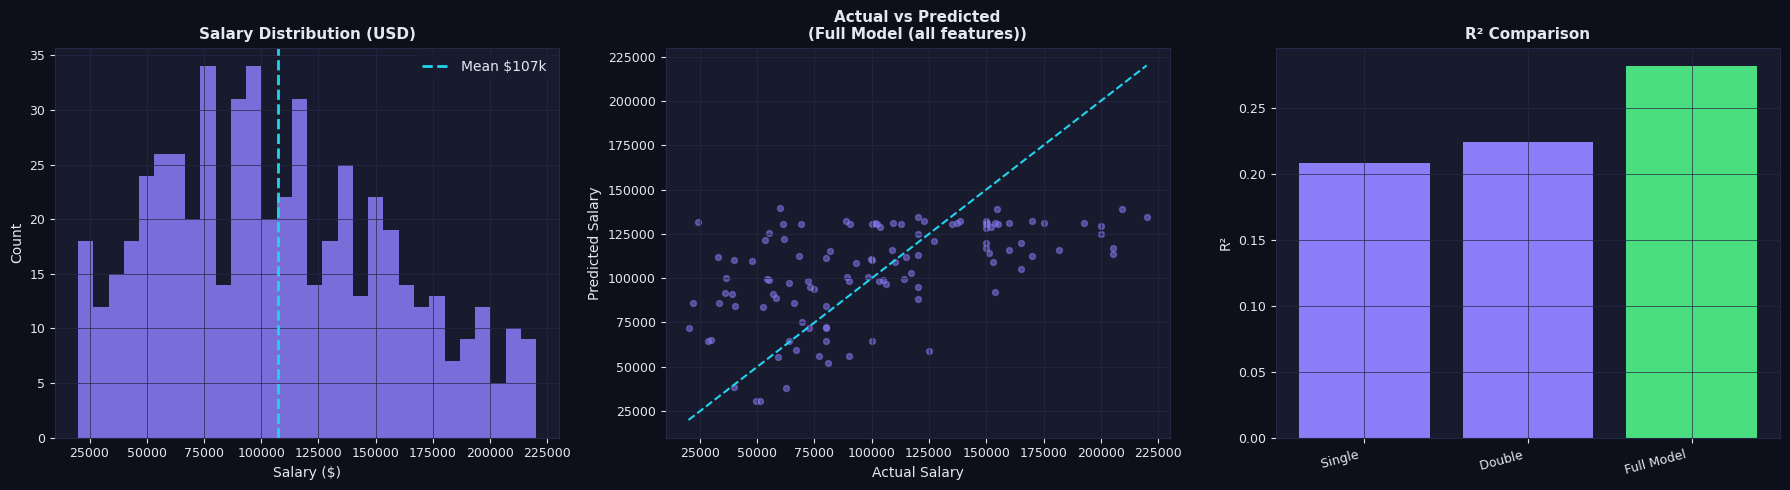

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0d0f1a")
PANEL, TXT, P, C, G = "#181b2e", "#e2e8f0", "#8b7cf8", "#22d3ee", "#4ade80"

def sax(ax, title):
    ax.set_facecolor(PANEL)
    for s in ax.spines.values(): s.set_edgecolor("#252844")
    ax.tick_params(colors=TXT, labelsize=9)
    ax.xaxis.label.set_color(TXT); ax.yaxis.label.set_color(TXT)
    ax.set_title(title, color=TXT, fontsize=11, fontweight="bold")
    ax.grid(color="#252844", lw=0.5)

# Plot 1 Salary distribution
sax(axes[0], "Salary Distribution (USD)")
axes[0].hist(y, bins=30, color=P, alpha=0.85, edgecolor="none")
axes[0].axvline(y.mean(), color=C, lw=2, ls="--", label=f"Mean ${y.mean()/1000:.0f}k")
axes[0].set_xlabel("Salary ($)"); axes[0].set_ylabel("Count")
axes[0].legend(labelcolor=TXT, facecolor=PANEL, edgecolor="none")

# Plot 2 Actual vs Predicted (best model shown later, use Full here)
best_name_tmp = max(metrics, key=lambda k: metrics[k]["R2"])
yp = metrics[best_name_tmp]["y_pred"]
sax(axes[1], f"Actual vs Predicted\n({best_name_tmp})")
axes[1].scatter(y_test, yp, color=P, alpha=0.5, s=18)
lims = [min(y_test.min(), yp.min()), max(y_test.max(), yp.max())]
axes[1].plot(lims, lims, color=C, lw=1.5, ls="--")
axes[1].set_xlabel("Actual Salary"); axes[1].set_ylabel("Predicted Salary")

# Plot 3 Model comparison bar
names  = list(metrics.keys())
r2s    = [metrics[k]["R2"] for k in names]
colors = [G if v == max(r2s) else P for v in r2s]
sax(axes[2], "R² Comparison")
axes[2].bar(range(len(names)), r2s, color=colors)
axes[2].set_xticks(range(len(names)))
axes[2].set_xticklabels([n.split("(")[0] for n in names], rotation=15, ha="right")
axes[2].set_ylabel("R²")

plt.tight_layout()
plt.savefig("/kaggle/working/comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [74]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

best_k_logo = max(metrics, key=lambda k: metrics[k]["CV_R2_mean"])
print(f"Using best model for LOGO CV : {best_k_logo}")

#Grouping column
if "work_year" in df_raw.columns:
    group_col_raw = "work_year"
    groups = df_raw.loc[df.index, "work_year"].values
    print(f"Grouping by : {group_col_raw}")
    print(f"Groups      : {np.unique(groups)}")
else:
    group_col_raw = "company_size"
    groups = df["company_size"].values
    print(f"Grouping by : {group_col_raw} (encoded)")
    print(f"Groups      : {np.unique(groups)}")

X_np = X_all.values
y_np = y.values

# Leave-One-Group-Out CV
logo     = LeaveOneGroupOut()
n_splits = logo.get_n_splits(X_np, y_np, groups)
print(f"\nLeave-One-Group-Out splits : {n_splits}")
print("Each fold: train on N-1 groups, test on held-out group\n")

logo_results = {}

for fold_i, (train_idx, test_idx) in enumerate(logo.split(X_np, y_np, groups)):
    held_out_group = np.unique(groups[test_idx])[0]

    Xtr_raw, Xte_raw = X_np[train_idx], X_np[test_idx]
    ytr,     yte     = y_np[train_idx],  y_np[test_idx]

    # Scale inside fold — no leakage
    fold_scaler = StandardScaler()
    Xtr_s = fold_scaler.fit_transform(Xtr_raw)
    Xte_s = fold_scaler.transform(Xte_raw)

    best_feat_idx = [ALL_FEATURES.index(f) for f in metrics[best_k_logo]["features"]]

    model = LinearRegression()
    model.fit(Xtr_s[:, best_feat_idx], ytr)
    y_pred = model.predict(Xte_s[:, best_feat_idx])

    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    r2   = r2_score(yte, y_pred)
    mae  = np.mean(np.abs(yte - y_pred))

    logo_results[held_out_group] = {"RMSE": rmse, "R2": r2, "MAE": mae, "n": len(yte)}
    print(f"  Held-out [{held_out_group}]  n={len(yte):4d}  "
          f"R²={r2:+.4f}  RMSE=${rmse:>9,.0f}  MAE=${mae:>8,.0f}")

# Generalization 
rmses = [v["RMSE"] for v in logo_results.values()]
r2s   = [v["R2"]   for v in logo_results.values()]
maes  = [v["MAE"]  for v in logo_results.values()]

print("\n" + "=" * 60)
print("  GENERALIZATION SUMMARY (Leave-One-Group-Out)")
print("=" * 60)
print(f"  Mean  R²   : {np.mean(r2s):+.4f}  (std={np.std(r2s):.4f})")
print(f"  Mean  RMSE : ${np.mean(rmses):>9,.0f}  (std=${np.std(rmses):,.0f})")
print(f"  Mean  MAE  : ${np.mean(maes):>9,.0f}  (std=${np.std(maes):,.0f})")

#Generalization Gap
in_sample_r2   = metrics[best_k_logo]["CV_R2_mean"]
out_of_dist_r2 = np.mean(r2s)
gap = in_sample_r2 - out_of_dist_r2

print(f"\n  In-sample CV R²    : {in_sample_r2:+.4f}")
print(f"  Out-of-dist R²     : {out_of_dist_r2:+.4f}")
print(f"  Generalization Gap : {gap:+.4f}", end="  ")

if abs(gap) < 0.05:
    print("✓ Good — model generalizes well")
elif gap > 0.1:
    print("⚠ Overfit expected on this dataset (temporal salary shift)")
else:
    print("~ Moderate — acceptable for this dataset size")


Using best model for LOGO CV : Full Model (all features)
Grouping by : work_year
Groups      : [2020 2021 2022]

Leave-One-Group-Out splits : 3
Each fold: train on N-1 groups, test on held-out group

  Held-out [2020]  n=  61  R²=+0.0556  RMSE=$   40,294  MAE=$  32,896
  Held-out [2021]  n= 182  R²=+0.1067  RMSE=$   45,965  MAE=$  38,449
  Held-out [2022]  n= 304  R²=-0.0252  RMSE=$   49,804  MAE=$  39,969

  GENERALIZATION SUMMARY (Leave-One-Group-Out)
  Mean  R²   : +0.0457  (std=0.0543)
  Mean  RMSE : $   45,355  (std=$3,906)
  Mean  MAE  : $   37,105  (std=$3,040)

  In-sample CV R²    : +0.1612
  Out-of-dist R²     : +0.0457
  Generalization Gap : +0.1155  ⚠ Overfit expected on this dataset (temporal salary shift)


In [76]:
# Select best model by CV R²
best_k = max(metrics, key=lambda k: metrics[k]["CV_R2_mean"])

#  Save trained model, scaler, encoders 
joblib.dump(metrics[best_k]["model"], "/kaggle/working/best_model.pkl")
joblib.dump(scaler,                   "/kaggle/working/scaler.pkl")
joblib.dump(label_encoders,           "/kaggle/working/label_encoders.pkl")

#Final Results Table
print("=" * 75)
print("  FINAL RESULTS  (Regression Metrics — RMSE/R²)")
print("=" * 75)
print(f"  {'Model':<35} {'R²':>6} {'CV R²':>7} {'±std':>6} {'Adj R²':>7} {'RMSE':>10} {'MAE':>9} {'MAPE':>7}")
print("  " + "-" * 72)
for k in metrics:
    m  = metrics[k]
    mk = "  ← BEST" if k == best_k else ""
    print(f"  {k:<35} {m['R2']:>6.4f} {m['CV_R2_mean']:>7.4f} {m['CV_R2_std']:>6.4f} "
          f"{m['AdjR2']:>7.4f} ${m['RMSE']:>8,.0f} ${m['MAE']:>7,.0f} "
          f"{m['MAPE']:>6.1f}%{mk}")

print(f"""
  Best Model : {best_k}
  Features   : {metrics[best_k]['features']}
  Saved to   : /kaggle/working/best_model.pkl
               /kaggle/working/scaler.pkl
               /kaggle/working/label_encoders.pkl
""")

  FINAL RESULTS  (Regression Metrics — RMSE/R²)
  Model                                   R²   CV R²   ±std  Adj R²       RMSE       MAE    MAPE
  ------------------------------------------------------------------------
  Single (experience_level)           0.2081  0.1464 0.0334  0.2008 $  43,458 $ 35,249   52.7%
  Double (exp + remote_ratio)         0.2244  0.1567 0.0321  0.2099 $  43,008 $ 34,494   51.0%
  Full Model (all features)           0.2815  0.1612 0.0566  0.2396 $  41,395 $ 33,361   49.3%  ← BEST

  Best Model : Full Model (all features)
  Features   : ['experience_level', 'employment_type', 'company_size', 'job_title', 'remote_ratio', 'years_since_start']
  Saved to   : /kaggle/working/best_model.pkl
               /kaggle/working/scaler.pkl
               /kaggle/working/label_encoders.pkl



In [73]:
#Inference
sample_dict = {}

for col in ALL_FEATURES:
    if col in label_encoders:
        le = label_encoders[col]
        
        if col == "experience_level":
            val = "SE"          # Senior Engineer
        elif col == "employment_type":
            val = "FT"          # Full Time
        elif col == "company_size":
            val = "L"           # Large company
        elif col == "job_title":
            val = "Data Scientist"   # Common job title
        else:
            val = le.classes_[0]  
        if val in le.classes_:
            sample_dict[col] = le.transform([val])[0]
        else:
            sample_dict[col] = le.transform([le.classes_[0]])[0]

    elif col == "remote_ratio":
        sample_dict[col] = 100     
    elif col == "work_year":
        sample_dict[col] = 2022    
    else:
        sample_dict[col] = 0

sample = pd.DataFrame([sample_dict])

print("Sample input (before scaling):")
for col in ALL_FEATURES:
    raw_val = sample_dict[col]
    if col in label_encoders:
        decoded = label_encoders[col].inverse_transform([int(raw_val)])[0]
        print(f"  {col:<25} = {raw_val}  ({decoded})")
    else:
        print(f"  {col:<25} = {raw_val}")

#Scale
sample_scaled = pd.DataFrame(
    scaler.transform(sample[ALL_FEATURES]),
    columns=ALL_FEATURES
)

# Predict
best_features = metrics[best_k]["features"]
pred_salary   = metrics[best_k]["model"].predict(sample_scaled[best_features])[0]

# cuML numpy scalar fix
if hasattr(pred_salary, "item"):
    pred_salary = pred_salary.item()

print(f"\nPredicted Salary : ${pred_salary:,.2f}")
print(f"Model used       : {best_k}")
print(f"Features used    : {best_features}")

Sample input (before scaling):
  experience_level          = 3  (SE)
  employment_type           = 2  (FT)
  company_size              = 0  (L)
  job_title                 = 20  (Data Scientist)
  remote_ratio              = 100
  years_since_start         = 0

Predicted Salary : $117,800.50
Model used       : Full Model (all features)
Features used    : ['experience_level', 'employment_type', 'company_size', 'job_title', 'remote_ratio', 'years_since_start']
